[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/Stokes_1st_problem.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to visualize the unsteady solution to Stokes' 1st problem of the impulsively moved plate/wall, and explain the concept of self-similarity.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [21]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.optimize import fsolve
# special functions
from scipy.special import erf

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# STOKES' 1<sup>st</sup> PROBLEM

The problem of the unidirectional flow caused by an impulsively moved plate was first considered by [G. G. Stokes](https://en.wikipedia.org/wiki/Sir_George_Stokes,_1st_Baronet) in his 1850 treatise "On the effect of the internal friction of fluids on the motion of pendulums" published in the [_Transactions of the Cambridge Philosophical Society_](https://archive.org/details/b22464074/page/92/mode/2up) (strating on page 93 therein). [Lord Rayleigh](https://en.wikipedia.org/wiki/John_William_Strutt,_3rd_Baron_Rayleigh) also provided a solution in 1911 in an [article](https://www.tandfonline.com/doi/abs/10.1080/14786440608637084) in the more widely circulated [_Philosophical Magazine_](https://en.wikipedia.org/wiki/Philosophical_Magazine).

For some _very thorny_ issues related to Stokes' 1st problem for certain viscoelastic (non-Newtonian) fluids, see [my article](https://arxiv.org/abs/1009.4416).

# Visualization of the solution

In dimensionless form, ${v}_x^* = v_x/V_0$, the solution we derived in class (see also Section 7.7 of Panton) is
$$
\frac{v_x}{V_0} (y,t) = 1 - \mathrm{erf}\left(\frac{y}{2\sqrt{\nu t}}\right) = 1 - \frac{2}{\sqrt{\pi}}\int_{0}^{y/(2\sqrt{\nu t})} e^{-\hat{\eta}^2} \,d\hat{\eta},
$$
using the definition of the so-called [_error function_](https://en.wikipedia.org/wiki/Error_function) `erf`, which we imported above from [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erf.html).

Observe that $\eta = y/(2\sqrt{\nu t})$ is the _dimensionless_ similarity variable.

The form of the solution, $v_x/V_0 = f(\eta) = 1 - \mathrm{erf}(\eta)$, has no free parameters, it is _universal_.

Here's the plot:

In [22]:
# define the self-similar solution as a function
def f_selfsimilar(eta):
    return 1 - erf(eta)

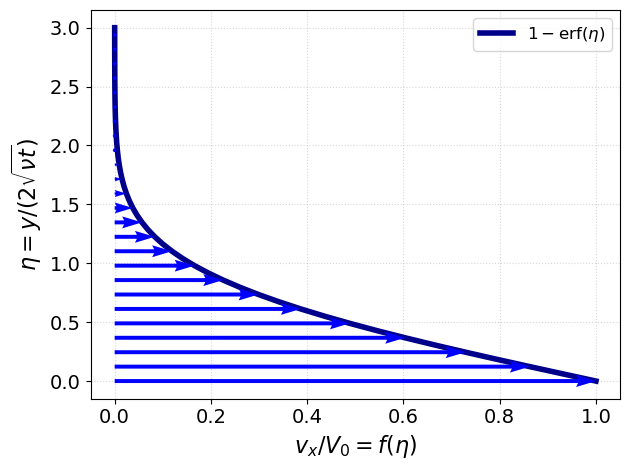

In [23]:
# define vertical extent of the eta plot and grid
etamax = 3.0
eta = np.linspace(0, etamax)

# set up the figure and axis
fig, ax = plt.subplots(tight_layout=True)
# need the 'r' to get Greek letters to show
ax.set_ylabel(r'$\eta = y/(2\sqrt{\nu t})$')
ax.set_xlabel(r'$v_x/V_0 = f(\eta)$')

vx = f_selfsimilar(eta)

ax.plot(vx, eta,
        linewidth=4, color='darkblue', label=r'$1-\mathrm{erf}(\eta)$')
# skip every other data point to reduce number of arrows
ax.quiver(0*eta[::2], eta[::2], vx[::2], 0*eta[::2],
          scale=1., scale_units='xy', color='blue', zorder=2)

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

## Discussion: the self-similarity concept

The solution found is unsteady, so we may wish to see it at different instants of $t$, as function of $y$.

On the right, we will also _rescale_ the solution back to the $\eta$-plane, to highlight how the self-similar transformation _collapses_ all the functions of $y$, at different $t$, onto the _universal_ profile!

In [24]:
# kinematic viscosity of water
nu = 1  # mm^2/s, so time will be in s and distance in mm for the plots below

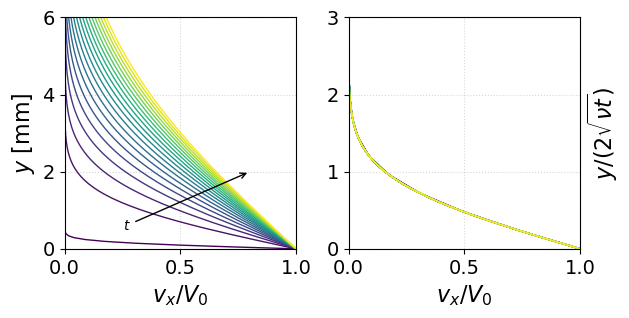

In [25]:
# define vertical extent of the y plot and grid
ymax = 12.0
y = np.linspace(0, ymax, 250)

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_ylabel('$y$ [mm]')
ax[0].set_ylim(0, ymax/2)
ax[0].set_xlabel('$v_x/V_0$')
ax[0].set_xlim(0, 1)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')
ax[0].grid(alpha=0.5, linestyle='dotted')

ax[1].set_ylabel(r'$y/(2\sqrt{\nu t})$')
ax[1].set_ylim(0, etamax)
ax[1].set_xlabel('$v_x/V_0$')
ax[1].set_xlim(0, 1)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].yaxis.set_label_position('right')
ax[1].grid(alpha=0.5, linestyle='dotted')

tmax = 10
for t in np.linspace(0.01, tmax, 20):
    vx = f_selfsimilar(y/(2*np.sqrt(nu*t)))
    randcol = cmap(t/tmax)  # argument from 0 to 1
    ax[0].plot(vx, y, linewidth=1, color=randcol)
    ax[1].plot(vx, y/(2*np.sqrt(nu*t)), linewidth=1, color=randcol)

ax[0].annotate('$t$', xy=(0.8, 2), 
               xytext=(0.25, 0.5), arrowprops=dict(arrowstyle="->"));

We can also illustrate the solution as an animation.

In [26]:
# define vertical extent of the y plot and grid
ymax = 12.0
y = np.linspace(0, ymax, 250)

# get a colormap
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_ylabel('$y$ [mm]')
ax[0].set_ylim(0, ymax/2)
ax[0].set_xlabel('$v_x/V_0$')
ax[0].set_xlim(0, 1)
# ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')
ax[0].grid(alpha=0.5, linestyle='dotted')

ax[1].set_ylabel(r'$y/(2\sqrt{\nu t})$')
ax[1].set_ylim(0, etamax)
ax[1].set_xlabel('$v_x/V_0$')
ax[1].set_xlim(0, 1)
# ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].grid(alpha=0.5, linestyle='dotted')
# if you want to move horizontal axis label to top so it doesn't clash with animation controls
# but tight_layout = True also fixes this
# ax[0].xaxis.set_label_position('top')
# ax[1].xaxis.set_label_position('top')
ax[1].yaxis.set_ticks_position('right')
ax[1].yaxis.set_label_position('right')
plt.close()

# initialize plot and quiver objects with some dummy data (replaced in animation)
ax[0].plot(0*y, y, linewidth=1, color=cmap(0))
ax[1].plot(0*eta, eta, linewidth=1, color=cmap(0))

time_label = ax[0].annotate('$t=0$', xy=(0.65, 0.9*ymax/2))

# number of animation frames
numframes = 50
tmax = 15

# animation function called sequentially by `FuncAnimation' below
def animate(t):
    # the t passed is actually the frame counter, not time
    # so it should be rescaled to get actual time as % of the frames
    # also shift it slightly so we don't divide by 0
    tt = 0.01 + t/numframes * tmax

    vx = f_selfsimilar(y/(2*np.sqrt(nu*tt)))
    randcol = cmap(tt/tmax)  # argument from 0 to 1
    ax[0].plot(vx, y, linewidth=1, color=randcol)
    ax[1].plot(vx, y/(2*np.sqrt(nu*tt)), linewidth=1, color=randcol)

    # dynamic time label in the corner
    time_label.set_text(f'$t={tt:.2f}$ s')

    return fig,


anim = animation.FuncAnimation(fig, animate,
                               frames=numframes, interval=300, blit=True, repeat=False)

In [27]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
display(anim)

In [28]:
# To save the animation, use e.g.
# ani.save(f"Stokes_1st_prob_movie.mp4")

# or
# writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save(f"Stokes_1st_prob_movie.mp4", writer=writer)

## Discussion: the viscous laminar "boundary layer" thickness

From this animation, we observe that the velocity variation is initially confined to a "boundary layer" near the plate. This "boundary layer" grows with time on the left, but appears to be of finite thickness in the self-similar plot on the right.

Let us calculate the "boundary layer thickness" in the self-similar coordinates by solving for the value of $\eta=\eta_{1\%}$ such that $v_x/V_0=0.01$ (equivalently, $\eta$ such that $v_x = 0.01V_0$). The value $\eta_{1\%}$ represents the distance above the plate, in the self-similar coordinates, at which the velocity has decayed to a mere 1% of the plate's velocity.

This requires using some [SciPy](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding) nonlinear root-finding capabilities.

In [29]:
def eq_func(eta1pc):
    # define a function v/V0(eta) - 0.01, which = 0 for the value
    # of \eta = \eta_{1\%} that we seek as a solution;
    return f_selfsimilar(eta1pc) - 0.01

eta1pc_initial_guess = 1
eta1pcsol = fsolve(eq_func, eta1pc_initial_guess)
eta1pcsol[0]

Therefore, the "boundary layer thickness" is $\eta_{1\%} \approx 1.82$.

The corresponding $y$ location, call it $y=\delta$, depends on time as the "boundary layer" grows (or as "momentum diffuses upwards from the moving plate"). From the definition of $\eta$, we have
$$ \eta_{1\%} = \frac{\delta}{2\sqrt{\nu t}} \approx 1.82 \quad\Rightarrow\quad \delta \approx 3.64 \sqrt{\nu t}.$$

We can show this thickness on the first plot we made above as:

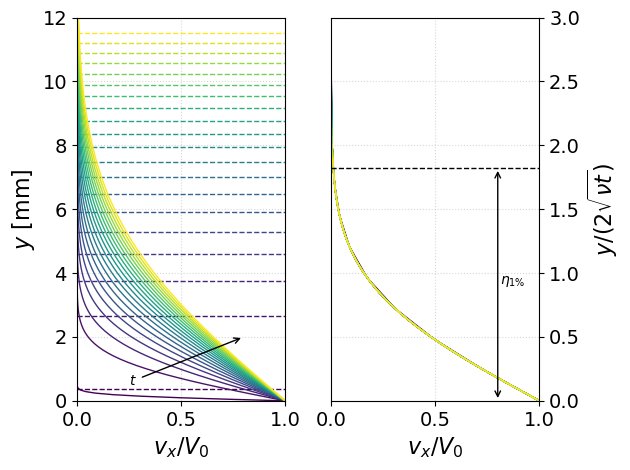

In [30]:
# define vertical extent of the y plot and grid
ymax = 12.0
y = np.linspace(0, ymax, 250)

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_ylabel('$y$ [mm]')
ax[0].set_ylim(0, ymax)
ax[0].set_xlabel('$v_x/V_0$')
ax[0].set_xlim(0, 1)
# ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')
ax[0].grid(alpha=0.5, linestyle='dotted')
ax[0].yaxis.set_label_position('left')
ax[0].yaxis.set_ticks_position('left')

ax[1].set_ylabel(r'$y/(2\sqrt{\nu t})$')
ax[1].set_ylim(0, etamax)
ax[1].set_xlabel('$v_x/V_0$')
ax[1].set_xlim(0, 1)
# ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].grid(alpha=0.5, linestyle='dotted')
ax[1].yaxis.set_ticks_position('right')
ax[1].yaxis.set_label_position('right')

tmax = 10
for t in np.linspace(0.01, tmax, 20):
    vx = f_selfsimilar(y/(2*np.sqrt(nu*t)))
    randcol = cmap(t/tmax)  # argument from 0 to 1
    ax[0].plot(vx, y, linewidth=1, color=randcol)
    ax[0].plot(np.linspace(0, 1), 
               np.sqrt(nu*t)*2*eta1pcsol[0]*np.ones_like(np.linspace(0, 1)),
               linewidth=1, color=randcol, linestyle='dashed')
    ax[1].plot(vx, y/(2*np.sqrt(nu*t)), linewidth=1, color=randcol)

ax[1].plot(np.linspace(0, 1), eta1pcsol[0]*np.ones_like(np.linspace(0, 1)),
           linewidth=1, color='black', linestyle='dashed')

# add nice arrows
ax[1].text(0.81, eta1pcsol[0]/2, r'$\eta_{1\%}$')
ax[1].annotate("", (0.8, 0), (0.8, eta1pcsol[0]),
               arrowprops={'arrowstyle': '<->'})

ax[0].annotate('$t$', xy=(0.8, 2), 
               xytext=(0.25, 0.5), arrowprops=dict(arrowstyle="->"));

# FURTHER EXPLORATION

On your own:
* Compute the vorticity of this flow, and study how it evolves. 
    - How many nonzero components does the vorticity vector of such a flow have?
    - Is it also localized to a "boundary layer"?
* Compute the viscous shear stress on the plate, and study how it evolves. What happens to the stresses for $t\to0$ or $t\to\infty$?